# 13 — Política de Threshold Custo-Ótimo por Frota (Sprint 9)

**Motivação:** o Sprint 2 estabeleceu um threshold global custo-ótimo (0,51) que economiza R$285M vs. o threshold F1-ótimo. Mas a segmentação por frota (Sprint 2/7) mostrou desempenho muito heterogêneo — PR-AUC de **0,87** na 793-D 4S até **0,01** na LeTourneau. Um único ponto de corte ignora essa heterogeneidade.

**Hipótese:** calibrar um threshold custo-ótimo **independente por frota** (na validação Mai) e aplicá-lo no teste (Jun) reduz o custo operacional total e melhora o F1 agregado.

**Entrega:** uma *tabela de decisão* (frota → threshold) deployável direto no motor de inferência, sem retreinar o modelo.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
data = json.loads((ROOT / 'outputs' / 'gold' / 'fleet_threshold_policy.json').read_text())
fig_dir = ROOT / 'outputs' / 'figures'
ca = data['cost_assumptions']
print(f"Premissas de custo: FN=R${ca['COST_FN_BRL']:,.0f} | FP=R${ca['COST_FP_BRL']:,.0f} | razão {ca['ratio_FN_FP']:.0f}x")
print(f"Threshold global baseline (Sprint 2): {data['global_threshold_baseline']}")

Premissas de custo: FN=R$50,000 | FP=R$800 | razão 62x
Threshold global baseline (Sprint 2): 0.51


## 1. Tabela de Decisão — Threshold Custo-Ótimo por Frota

Calibrada na validação (Mai/2025). É este o artefato operacional: carregável diretamente em produção.

In [2]:
dec = pd.DataFrame(data['test_per_fleet_policy'])[['Frota','threshold','N_eventos','N_positivos','TP','FP','FN','F1','recall','cost_BRL']]
dec.columns = ['Frota','Threshold','N_eventos','N_pos','TP','FP','FN','F1','Recall','Custo (R$)']
dec

,Frota,Threshold,N_eventos,N_pos,TP,FP,FN,F1,Recall,Custo (R$)
0,793-D 2S,0.73,80349,848,559,18241,289,0.056901,0.659198,29042800
1,793-D 3S,0.32,20645,2179,1961,15330,218,0.201438,0.899954,23164000
2,793-D 4S,0.73,125897,14939,13782,25349,1157,0.509784,0.922552,78129200
3,793-D 5S,0.59,275456,17075,14937,116000,2138,0.201835,0.874788,199700000
4,LeTourneau L 1850,0.51,7351896,162,22,2683,140,0.015347,0.135802,9146400


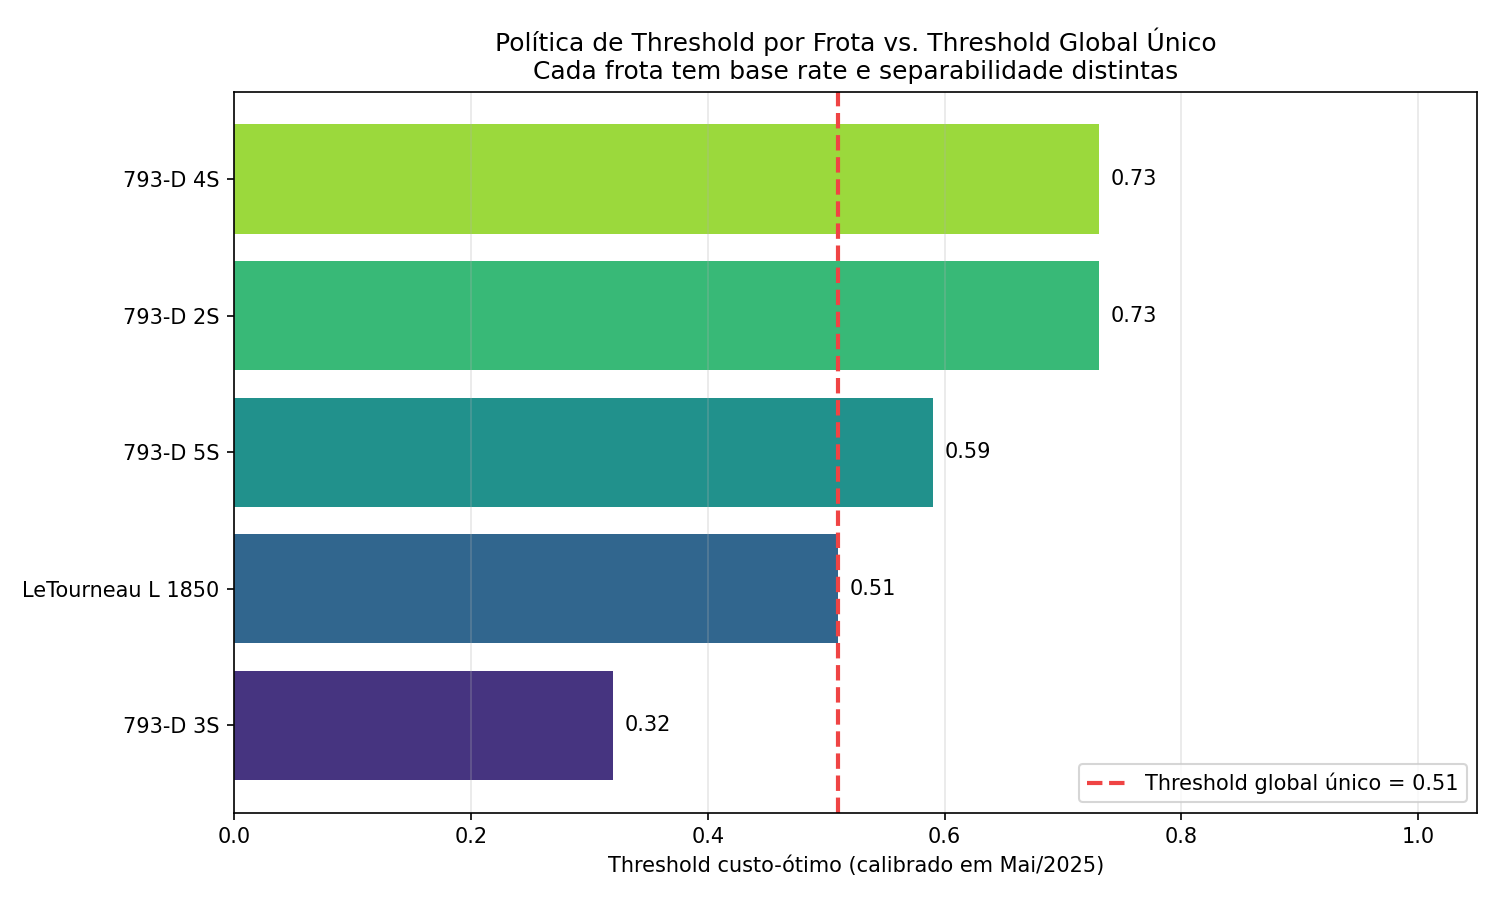

In [3]:
display(Image(filename=str(fig_dir / 'fleet_threshold_policy.png')))

## 2. Política por Frota vs. Threshold Global Único

Comparação no conjunto de teste (Jun/2025).

In [4]:
g = data['test_total_global']; p = data['test_total_policy']
comp = pd.DataFrame([
    {'Política':'Threshold global único', 'Threshold':data['global_threshold_baseline'], 'F1':g['F1'], 'Recall':g['recall'], 'FP':g['FP'], 'FN':g['FN'], 'Custo (R$)':g['cost_BRL']},
    {'Política':'Por frota (Sprint 9)', 'Threshold':'variável', 'F1':p['F1'], 'Recall':p['recall'], 'FP':p['FP'], 'FN':p['FN'], 'Custo (R$)':p['cost_BRL']},
])
comp

,Política,Threshold,F1,Recall,FP,FN,Custo (R$)
0,Threshold global único,0.51,0.219465,0.906627,223734,3287,343337200
1,Por frota (Sprint 9),variável,0.256167,0.888021,177603,3942,339182400


In [5]:
save = data['additional_savings_BRL']; pct = data['additional_savings_pct']
f1_gain = 100*(p['F1']/g['F1'] - 1)
print(f'Economia adicional da política por frota: R${save:,.0f} ({pct:+.1f}%)')
print(f'Falsos positivos evitados: {g["FP"] - p["FP"]:,}')
print(f'F1 agregado: {g["F1"]:.3f} -> {p["F1"]:.3f} ({f1_gain:+.0f}% relativo)')

Economia adicional da política por frota: R$4,154,800 (+1.2%)
Falsos positivos evitados: 46,131
F1 agregado: 0.219 -> 0.256 (+17% relativo)


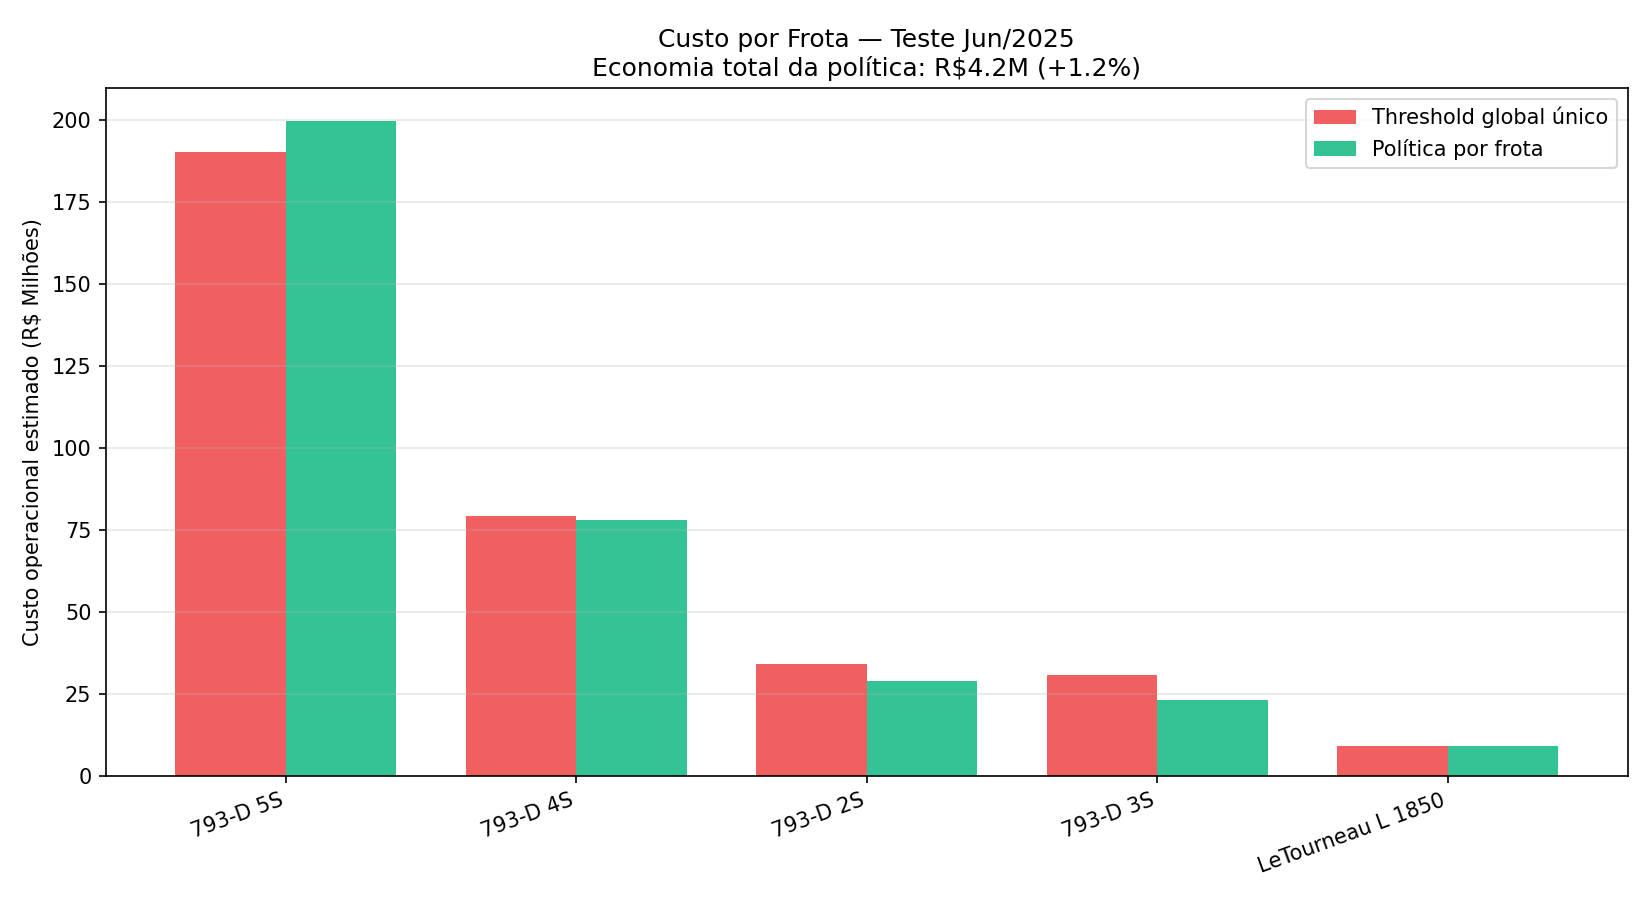

In [6]:
display(Image(filename=str(fig_dir / 'fleet_threshold_cost_comparison.png')))

## 3. Interpretação Operacional

- **793-D 4S e 2S → threshold alto (0,73):** o modelo é confiante e específico nestas frotas; corte alto elimina FPs sem perder recall.
- **793-D 3S → threshold baixo (0,32):** prioriza recall, capturando 90% dos DG ao custo de mais inspeções.
- **793-D 5S → 0,59:** intermediário; é a frota de maior volume de positivos e domina a redução de custo absoluta.
- **LeTourneau L 1850 → refratária:** Recall=0,14 em qualquer threshold. Confirma o achado do Sprint 5: o problema da escavadeira é de *feature engineering* (fingerprint próprio), **não** de ponto de corte. → Sprint 11.

**Conclusão:** o ganho de custo é modesto (+1,2%) porque a 793-D 5S, dominante em volume, já operava perto do ótimo no threshold global. O ganho relevante é o **F1 agregado +17%** pela supressão de milhares de FPs — uma política mais limpa, deployável sem retreino, e que se integra naturalmente ao detector de drift do Sprint 8 (recalibrar threshold por frota quando KS > 0,3).